In [68]:
#Import all packages
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import expm
from matplotlib.colors import hsv_to_rgb
from scipy.optimize import linprog

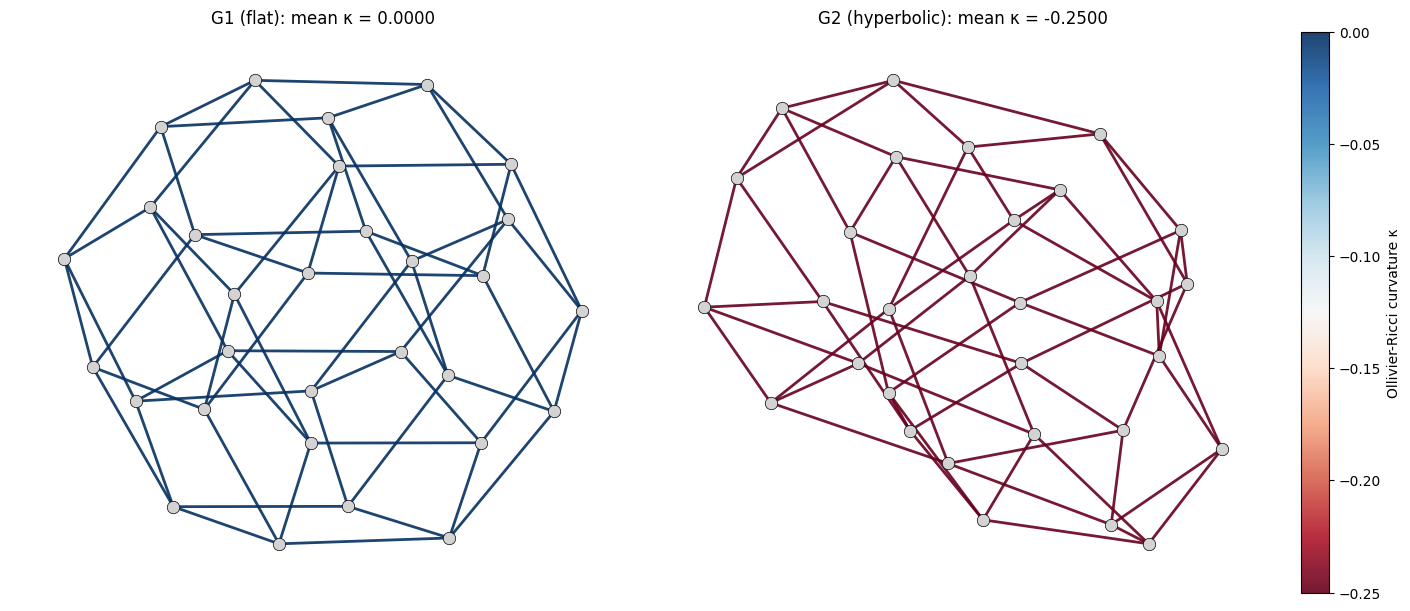

In [69]:
#Model 1: 30 neuron network

#First, flat neuron
def build_graph_cell1(rows=5, cols=6):
    G = nx.grid_2d_graph(rows,cols, periodic=True)
    mapping = {(r, c): r * cols + c for r, c in G.nodes()}
    return nx.relabel_nodes(G, mapping, copy=True)

#Second, hyperbolic network:
def build_graph_cell2():
    adj = {
        0:  [11,12,18,19],
        1:  [2, 10, 23, 14],
        2:  [1, 3, 13, 14],
        3:  [2, 4, 13, 17],
        4:  [3, 5, 16, 17],
        5:  [4, 6, 16, 20],
        6:  [5, 7, 19, 20],
        7:  [6, 8, 19, 22],
        8:  [9, 7, 21, 22],
        9:  [8, 10, 11, 21],
        10: [1, 9, 11, 23],
        11: [10, 12, 9, 0],
        12: [11, 13, 28, 0],
        13: [2, 3, 12, 28],
        14: [1, 2, 29, 15],
        15: [14, 16, 24, 29],
        16: [4, 5, 15, 24],
        17: [3, 4, 18, 26],
        18: [17, 19, 26, 0],
        19: [6, 7, 18, 0],
        20: [5, 6, 27, 28],
        21: [8, 9, 27, 29],
        22: [7, 8, 24, 25],
        23: [1, 10, 25, 26],
        24: [15, 16, 22, 25],
        25: [22, 23, 24, 26],
        26: [17, 18, 23, 25],
        27: [20, 21, 28, 29],
        28: [12, 13, 20, 27],
        29: [14, 15, 21, 27],
    }
    G = nx.Graph()
    for u, nbrs in adj.items():
        for v in nbrs:
            G.add_edge(u,v)
    return G

#Compute Ollivier-Ricci curvature
def ollivier_ricci_curvature(G, u, v, alpha=0.0):
    Nu = list(G.neighbors(u))
    Nv = list(G.neighbors(v))
    supp_u = [u] + Nu
    supp_v = [v] + Nv
    all_nodes = list(set(supp_u + supp_v))
    node_idx = {node: i for i, node in enumerate(all_nodes)}
    m = len(all_nodes)
    mu = np.zeros(m)
    mv = np.zeros(m)
    mu[node_idx[u]] = alpha
    for nb in Nu:
        mu[node_idx[nb]] += (1 - alpha) / len(Nu)
    
    mv[node_idx[v]] = alpha
    for nb in Nv:
        mv[node_idx[nb]] += (1 - alpha) / len(Nv)
    D = np.zeros((m,m))
    for i, ni in enumerate(all_nodes):
        for j, nj in enumerate(all_nodes):
            if i <= j:
                d = nx.shortest_path_length(G, ni, nj)
                D[i, j] = d
                D[j, i] = d 
    c = D.flatten()
    A_eq = []
    b_eq = []
    for i in range(m):
        row = np.zeros(m * m)
        row[i * m: (i+1) *m] = 1.0
        A_eq.append(row)
        b_eq.append(mu[i])
    for j in range(m):
        col = np.zeros(m * m)
        col[j::m] = 1.0
        A_eq.append(col)
        b_eq.append(mv[j])
    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)
    bounds = [(0, None)] * (m * m)
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    W1 = res.fun
    d_uv = nx.shortest_path_length(G, u, v)
    return 1.0 - W1 / d_uv

#Create G1: flat and G2: Hyperbolic
G1 = build_graph_cell1(rows=5, cols=6)
G2 = build_graph_cell2()

#visualize Ollivier-Ricci curvature
G1_edge_curvatures = {}
for u, v in G1.edges():
    kappa = ollivier_ricci_curvature(G1, u, v, alpha=0.0)
    G1_edge_curvatures[(u, v)] = kappa
G1_curvature_vals = np.array(list(G1_edge_curvatures.values()))

G2_edge_curvatures = {}
for u, v in G2.edges():
    kappa = ollivier_ricci_curvature(G2, u, v, alpha=0.0)
    G2_edge_curvatures[(u, v)] = kappa
G2_curvature_vals = np.array(list(G2_edge_curvatures.values()))


# --- Side-by-side visualization of edge Ollivier-Ricci curvature for G1 and G2 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Use a shared color scale across both graphs
all_curv = np.concatenate([G1_curvature_vals, G2_curvature_vals])
vmin, vmax = float(all_curv.min()), float(all_curv.max())
pos1 = nx.spring_layout(G1, seed=0)
pos2 = nx.spring_layout(G2, seed=0)

# ---- G1 ----
edges1 = list(G1_edge_curvatures.keys())
colors1 = [G1_edge_curvatures[e] for e in edges1]

nx.draw_networkx_nodes(
    G1, pos1, ax=axes[0],
    node_size=80, node_color="lightgray",
    edgecolors="black", linewidths=0.5
)
ec1 = nx.draw_networkx_edges(
    G1, pos1, ax=axes[0],
    edgelist=edges1, edge_color=colors1,
    edge_cmap=plt.cm.RdBu, width=2.0, alpha=0.9,
    edge_vmin=vmin, edge_vmax=vmax
)
axes[0].set_title(f"G1 (flat): mean κ = {np.mean(G1_curvature_vals):.4f}")
axes[0].axis("off")

# ---- G2 ----
edges2 = list(G2_edge_curvatures.keys())
colors2 = [G2_edge_curvatures[e] for e in edges2]
nx.draw_networkx_nodes(
    G2, pos2, ax=axes[1],
    node_size=80, node_color="lightgray",
    edgecolors="black", linewidths=0.5
)
ec2 = nx.draw_networkx_edges(
    G2, pos2, ax=axes[1],
    edgelist=edges2, edge_color=colors2,
    edge_cmap=plt.cm.RdBu, width=2.0, alpha=0.9,
    edge_vmin=vmin, edge_vmax=vmax
)
axes[1].set_title(f"G2 (hyperbolic): mean κ = {np.mean(G2_curvature_vals):.4f}")
axes[1].axis("off")

cbar = fig.colorbar(ec2, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label("Ollivier-Ricci curvature κ")
plt.show()

In [ ]:
# ========== SHARED SIMULATION PARAMETERS AND UTILITIES ==========
# Modify only this cell to change parameters across all analyses

# --- Simulation Parameters ---
T_sim = 100                    # simulation time steps
dt_sim = 1.0                   # time step for evolution
input_node_indices = np.arange(8)  # which nodes receive input
I_dc_val = 0.0 + 0.01j         # DC input
I_amp_val = 0.0                # AC input amplitude
omega_val = 2 * np.pi / 10     # AC input frequency
phase0_val = np.pi / 4         # AC input phase

def phi(Z):
    """Activation function: Z / sqrt(1 + |Z|^2)"""
    return Z / np.sqrt(1.0 + np.abs(Z)**2)

def compute_L_and_U(graph, dt=1.0, use_combinatorial_laplacian=True):
    """
    Compute Laplacian L and evolution operator U = expm(i*L*dt)
    Returns: (L_real, U_unitary)
    """
    n = graph.number_of_nodes()
    A = nx.to_numpy_array(graph, nodelist=range(n), dtype=float)
    
    if use_combinatorial_laplacian:
        D = np.diag(A.sum(axis=1))
        L_real = D - A
    else:
        L_real = 4 * np.eye(n) - A
    
    # U must be unitary: U = expm(i * L * dt)
    U_unitary = expm(1j * dt * L_real)
    return L_real, U_unitary

def evolve_state(z, U, I_vec, steps=1):
    """
    Evolve state z for 'steps' timesteps using U and input I_vec
    Returns trajectory of |z| values: shape (steps+1, n)
    """
    n = z.shape[0]
    traj = np.zeros((steps + 1, n), dtype=float)
    traj[0] = np.abs(z)
    
    for t in range(1, steps + 1):
        z = phi(U @ z + I_vec)
        traj[t] = np.abs(z)
    
    return traj, z

# ========== END SHARED PARAMETERS ==========


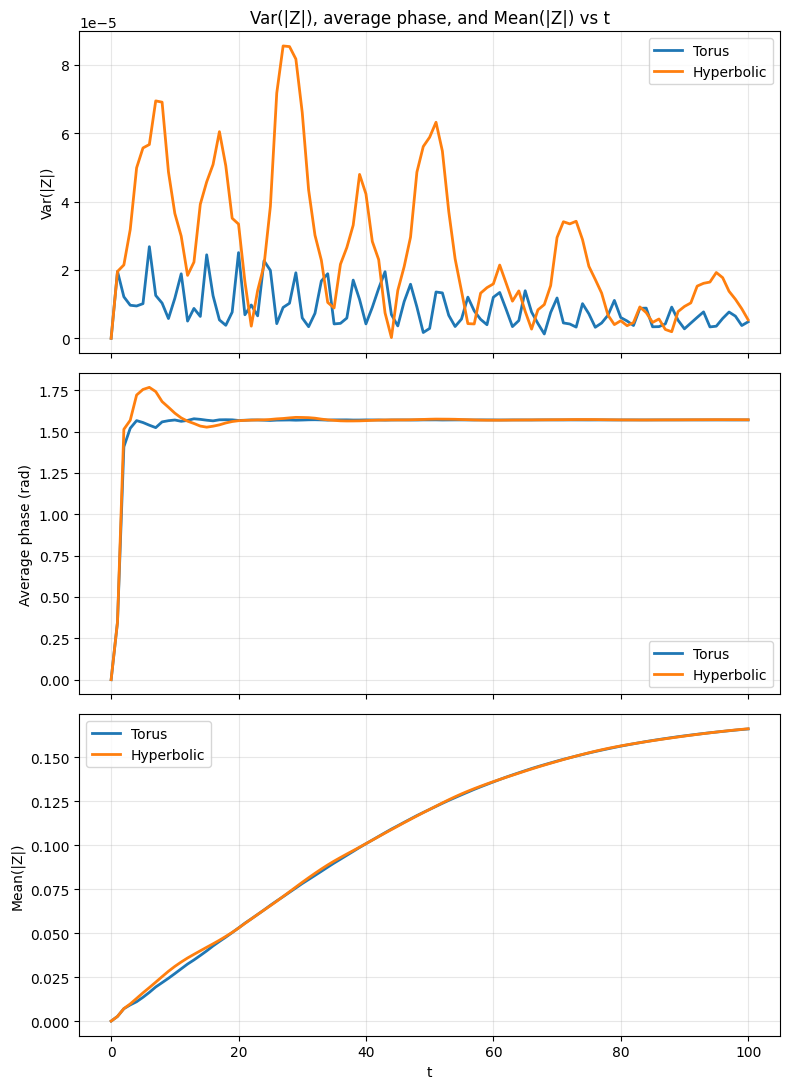

In [70]:
# Run both models
def phi(Z):
    return Z / np.sqrt(1.0 + np.abs(Z)**2)
def compute_curves(
        graph,
        T = 500,
        dt=1.0,
        input_nodes=(0,),
        I_dc = 0.0+0.01j,
        I_amp=0.000,
        omega=2 * np.pi / 50,
        phase0=0.0,
):
    n = graph.number_of_nodes()
    A_adj = nx.to_numpy_array(graph, nodelist=range(n), dtype=float)
    #L = 4*np.eye(n) - A_adj
    L = 1j * (4*np.eye(n)-A_adj)
    U = expm(L)
    z = np.zeros(n, dtype=np.complex128)

    t_axis = np.arange(T + 1)
    var_abs = np.empty(T + 1, dtype=float)
    mean_phase = np.empty(T + 1, dtype=float)
    mean_abs = np.empty(T + 1, dtype=float)
    var_abs[0] = np.var(np.abs(z))
    mean_phase[0] = np.angle(np.mean(np.exp(1j * np.angle(z))))
    mean_abs[0] = np.mean(np.abs(z))
    input_nodes = np.atleast_1d(input_nodes)
    for t in range(1, T + 1):
        I_t = I_dc + I_amp * np.exp(1j * (omega * t + phase0))
        I_vec = np.zeros(n, dtype=np.complex128)
        I_vec[input_nodes] = I_t
        z = phi(U @ z + I_vec)
        var_abs[t] = np.var(np.abs(z))
        mean_phase[t] = np.angle(np.mean(np.exp(1j * np.angle(z))))
        mean_abs[t] = np.mean(np.abs(z))
    return t_axis, var_abs, mean_phase, mean_abs

T_plot = 100
input_nodes = np.arange(8)
I_dc = 0.00 + 0.01j
I_amp = 0.0
omega = 2 * np.pi / 10
phase0 = np.pi / 4

# Run both graphs with same settings
t1, var1, phase1, mean1 = compute_curves(
    G1, T=T_plot, input_nodes=input_nodes, I_dc=I_dc, I_amp=I_amp, omega=omega, phase0=phase0
)
t2, var2, phase2, mean2 = compute_curves(
    G2, T=T_plot, input_nodes=input_nodes, I_dc=I_dc, I_amp=I_amp, omega=omega, phase0=phase0
)

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)

axes[0].plot(t1, var1, lw=2, label="Torus")
axes[0].plot(t2, var2, lw=2, label="Hyperbolic")
axes[0].set_ylabel("Var(|Z|)")
axes[0].set_title("Var(|Z|), average phase, and Mean(|Z|) vs t")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(t1, phase1, lw=2, label="Torus")
axes[1].plot(t2, phase2, lw=2, label="Hyperbolic")
axes[1].set_ylabel("Average phase (rad)")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(t1, mean1, lw=2, label="Torus")
axes[2].plot(t2, mean2, lw=2, label="Hyperbolic")
axes[2].set_xlabel("t")
axes[2].set_ylabel("Mean(|Z|)")
axes[2].grid(alpha=0.3)
axes[2].legend()


plt.tight_layout()
plt.show()

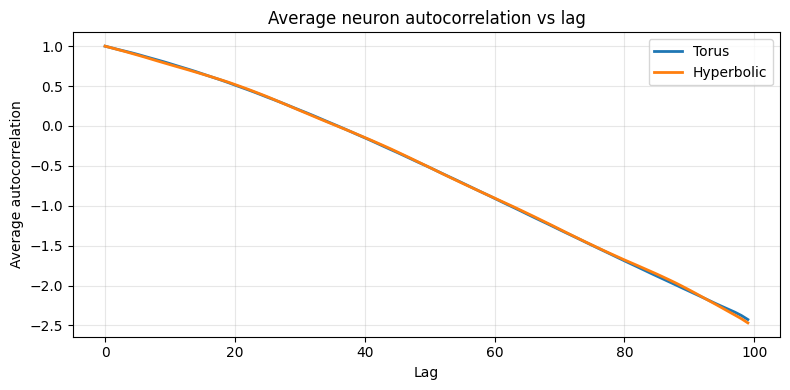

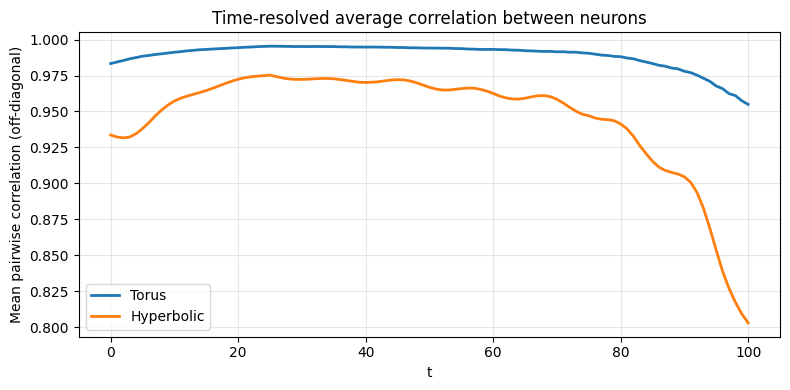

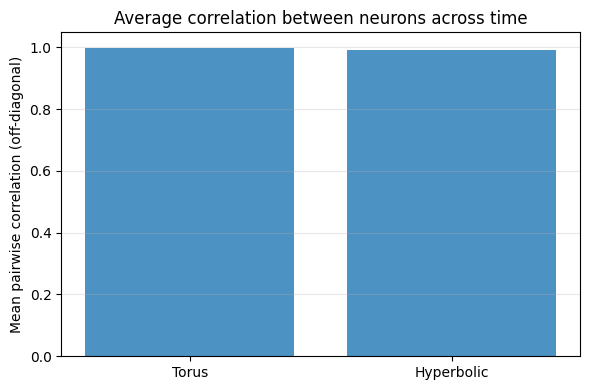

In [71]:
# Cell 4: autocorrelation (within neuron) and inter-neuron correlation (between neurons)

def simulate_abs_activity(
    graph,
    T=10,
    dt=1.0,
    input_nodes=(0,),
    I_dc=0.0 + 0.0j,
    I_amp=0.01,
    omega=2 * np.pi / 100,
    phase0=np.pi / 4,
):
    n = graph.number_of_nodes()
    A_adj = nx.to_numpy_array(graph, nodelist=range(n), dtype=float)
    L = np.diag(A_adj.sum(axis=1)) - A_adj
    L = 1j * (4 * np.eye(n) - A_adj)
    #L = 1j * (A_adj - 4*np.eye(n))

    U = expm(L)

    z = np.zeros(n, dtype=np.complex128)
    input_nodes = np.atleast_1d(input_nodes)

    abs_traj = np.empty((T + 1, n), dtype=float)
    abs_traj[0] = np.abs(z)

    for t in range(1, T + 1):
        I_t = I_dc + I_amp * np.exp(1j * (omega * t + phase0))
        I_vec = np.zeros(n, dtype=np.complex128)
        I_vec[input_nodes] = I_t
        z = phi(U @ z + I_vec)
        abs_traj[t] = np.abs(z)

    return abs_traj  # shape: (time, neuron)


def average_autocorr_over_neurons(X, max_lag=100):
    # X: (time, neuron)
    Tn, n = X.shape
    max_lag = min(max_lag, Tn - 2)
    lags = np.arange(max_lag + 1)
    ac = np.zeros((n, max_lag + 1), dtype=float)

    for j in range(n):
        x = X[:, j]
        x = x - x.mean()
        var = np.var(x)
        if var < 1e-12:
            continue
        ac[j, 0] = 1.0
        for k in range(1, max_lag + 1):
            ac[j, k] = np.dot(x[:-k], x[k:]) / ((Tn - k) * var)

    return lags, ac.mean(axis=0)


def mean_pairwise_corr(X):
    # X: (time, neuron)
    C = np.corrcoef(X.T)
    n = C.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return np.nanmean(C[mask]), C


# Simulate both graphs with same settings as cell 3
X1 = simulate_abs_activity(
    G1, T=T_plot, input_nodes=input_nodes, I_dc=I_dc, I_amp=I_amp, omega=omega, phase0=phase0
)
X2 = simulate_abs_activity(
    G2, T=T_plot, input_nodes=input_nodes, I_dc=I_dc, I_amp=I_amp, omega=omega, phase0=phase0
)

# 1) Average autocorrelation across neurons (vs lag)
lags1, ac1 = average_autocorr_over_neurons(X1, max_lag=120)
lags2, ac2 = average_autocorr_over_neurons(X2, max_lag=120)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lags1, ac1, lw=2, label="Torus")
ax.plot(lags2, ac2, lw=2, label="Hyperbolic")
ax.set_xlabel("Lag")
ax.set_ylabel("Average autocorrelation")
ax.set_title("Average neuron autocorrelation vs lag")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
# ...existing code...

def mean_pairwise_corr_over_time(X, window=50):
    # X: (time, neuron)
    Tn, n = X.shape
    half = window // 2
    t_axis = np.arange(Tn)
    mean_corr_t = np.full(Tn, np.nan, dtype=float)

    for t in range(Tn):
        a = max(0, t - half)
        b = min(Tn, t + half + 1)
        seg = X[a:b]  # (window_time, neuron)

        # Need at least 3 time points to estimate correlation robustly
        if seg.shape[0] < 3:
            continue

        C = np.corrcoef(seg.T)
        mask = ~np.eye(n, dtype=bool)
        mean_corr_t[t] = np.nanmean(C[mask])

    return t_axis, mean_corr_t

# 2) Time-resolved average correlation between neurons
t_corr1, corr_t1 = mean_pairwise_corr_over_time(X1, window=50)
t_corr2, corr_t2 = mean_pairwise_corr_over_time(X2, window=50)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_corr1, corr_t1, lw=2, label="Torus")
ax.plot(t_corr2, corr_t2, lw=2, label="Hyperbolic")
ax.set_xlabel("t")
ax.set_ylabel("Mean pairwise correlation (off-diagonal)")
ax.set_title("Time-resolved average correlation between neurons")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# ...existing code...
# 2) Average correlation between neurons (single summary value per graph)
mean_corr1, C1 = mean_pairwise_corr(X1)
mean_corr2, C2 = mean_pairwise_corr(X2)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Torus", "Hyperbolic"], [mean_corr1, mean_corr2], alpha=0.8)
ax.set_ylabel("Mean pairwise correlation (off-diagonal)")
ax.set_title("Average correlation between neurons across time")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



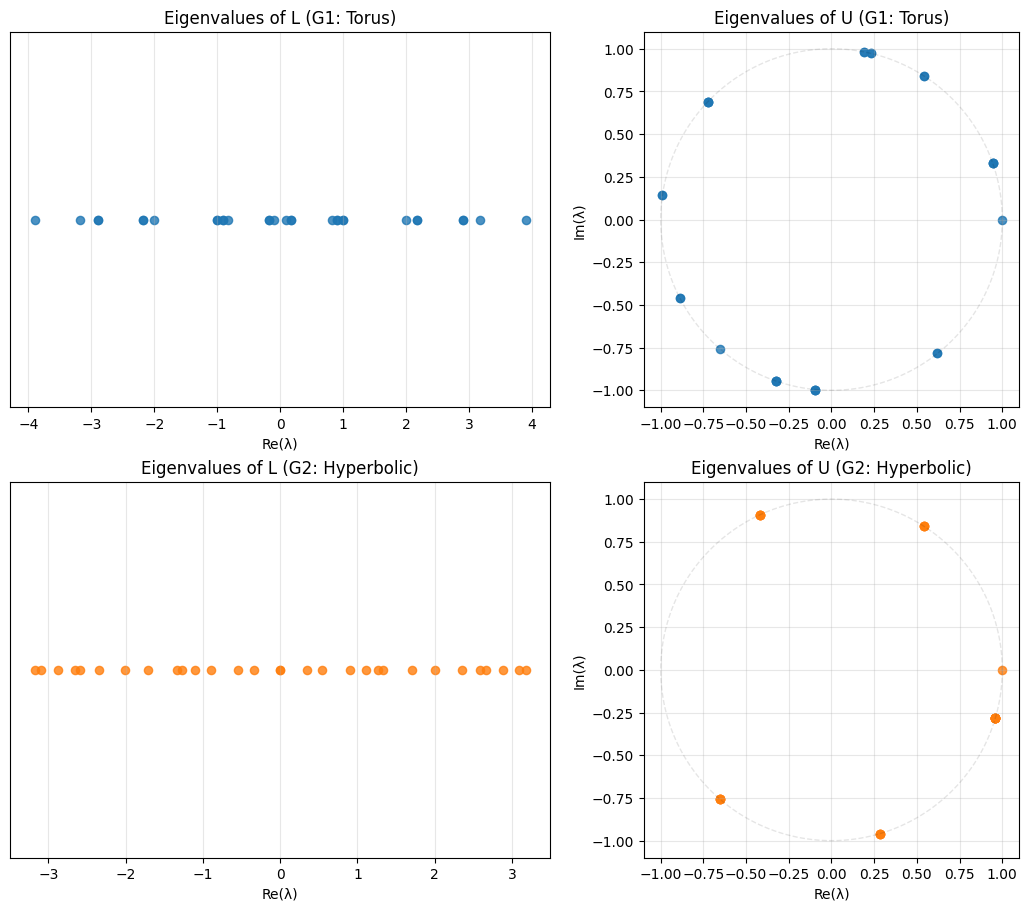

G1 spectral gap (lambda_2): 0.097887
G2 spectral gap (lambda_2): 0.343578
G1 spectral entropy (normalized): 0.893486
G2 spectral entropy (normalized): 0.947835


In [72]:
# Cell 5: Eigenvalue distributions, spectral gap, and spectral entropy

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

def build_L_U(graph, dt=1.0, use_combinatorial_laplacian=True):
    n = graph.number_of_nodes()
    A = nx.to_numpy_array(graph, nodelist=range(n), dtype=float)
    if use_combinatorial_laplacian:
        D = np.diag(A.sum(axis=1))
        L = 1j * (D - A)
    else:
        # Match your dynamics choice if needed:
        L = 1j * (4 * np.eye(n) - A)
    U = expm(L)
    return L, U

def spectral_gap(L, tol=1e-10):
    lam = np.sort(np.real_if_close(np.linalg.eigvalsh(L)))
    lam = np.real(lam)
    # Algebraic connectivity for connected graph: lambda_2
    # robust to tiny numerical zeros
    positive = lam[lam > tol]
    if len(positive) == 0:
        return 0.0
    return float(positive[0])

def spectral_entropy_from_laplacian(L, tol=1e-12, normalize=True):
    lam = np.real_if_close(np.linalg.eigvalsh(L)).astype(float)
    lam = lam[lam > tol]  # drop zero mode(s)
    if lam.size == 0:
        return 0.0
    p = lam / lam.sum()
    H = -np.sum(p * np.log(p))
    if normalize and len(p) > 1:
        H /= np.log(len(p))
    return float(H)

# Build operators
L1, U1 = build_L_U(G1, dt=1.0, use_combinatorial_laplacian=True)
L2, U2 = build_L_U(G2, dt=1.0, use_combinatorial_laplacian=True)

# Eigenvalues
eigL1 = np.linalg.eigvalsh(L1)     # real
eigL2 = np.linalg.eigvalsh(L2)     # real
eigU1 = np.linalg.eigvals(U1)      # complex
eigU2 = np.linalg.eigvals(U2)      # complex

# ---- Plot: 2x2 ----
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)

# Top-left: L of G1
axes[0, 0].scatter(np.real(eigL1), np.zeros_like(eigL1), s=35, alpha=0.8)
axes[0, 0].set_title("Eigenvalues of L (G1: Torus)")
axes[0, 0].set_xlabel("Re(λ)")
axes[0, 0].set_yticks([])
axes[0, 0].grid(alpha=0.3)

# Top-right: U of G1
axes[0, 1].scatter(np.real(eigU1), np.imag(eigU1), s=35, alpha=0.8)
theta = np.linspace(0, 2*np.pi, 400)
axes[0, 1].plot(np.cos(theta), np.sin(theta), "k--", lw=1, alpha=0.1)
axes[0, 1].set_aspect("equal", adjustable="box")
axes[0, 1].set_title("Eigenvalues of U (G1: Torus)")
axes[0, 1].set_xlabel("Re(λ)")
axes[0, 1].set_ylabel("Im(λ)")
axes[0, 1].grid(alpha=0.3)

# Bottom-left: L of G2
axes[1, 0].scatter(np.real(eigL2), np.zeros_like(eigL2), s=35, alpha=0.8, color="tab:orange")
axes[1, 0].set_title("Eigenvalues of L (G2: Hyperbolic)")
axes[1, 0].set_xlabel("Re(λ)")
axes[1, 0].set_yticks([])
axes[1, 0].grid(alpha=0.3)

# Bottom-right: U of G2
axes[1, 1].scatter(np.real(eigU2), np.imag(eigU2), s=35, alpha=0.8, color="tab:orange")
axes[1, 1].plot(np.cos(theta), np.sin(theta), "k--", lw=1, alpha=0.1)
axes[1, 1].set_aspect("equal", adjustable="box")
axes[1, 1].set_title("Eigenvalues of U (G2: Hyperbolic)")
axes[1, 1].set_xlabel("Re(λ)")
axes[1, 1].set_ylabel("Im(λ)")
axes[1, 1].grid(alpha=0.3)

plt.show()

# ---- Metrics ----
gap1 = spectral_gap(L1)
gap2 = spectral_gap(L2)

H1 = spectral_entropy_from_laplacian(L1, normalize=True)
H2 = spectral_entropy_from_laplacian(L2, normalize=True)

print(f"G1 spectral gap (lambda_2): {gap1:.6f}")
print(f"G2 spectral gap (lambda_2): {gap2:.6f}")
print(f"G1 spectral entropy (normalized): {H1:.6f}")
print(f"G2 spectral entropy (normalized): {H2:.6f}")

In [73]:
print(U1.shape, U2.shape)



(30, 30) (30, 30)


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

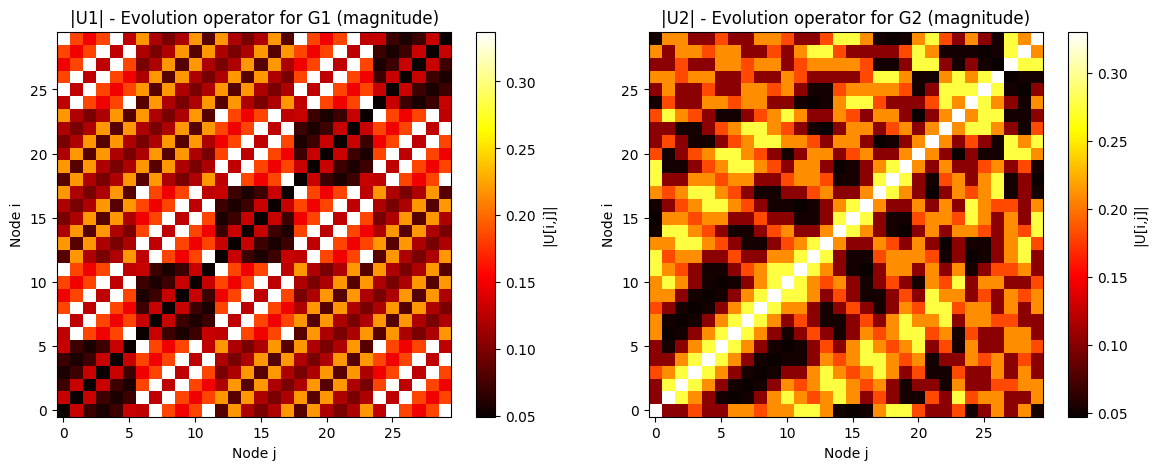

In [74]:

# Heatmaps of U matrices for G1 and G2
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# U1 heatmap (magnitude)
im1 = axes[0].imshow(np.abs(U1), cmap='hot', aspect='auto', origin='lower')
axes[0].set_title('|U1| - Evolution operator for G1 (magnitude)')
axes[0].set_xlabel('Node j')
axes[0].set_ylabel('Node i')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('|U[i,j]|')

# U2 heatmap (magnitude)
im2 = axes[1].imshow(np.abs(U2), cmap='hot', aspect='auto', origin='lower')
axes[1].set_title('|U2| - Evolution operator for G2 (magnitude)')
axes[1].set_xlabel('Node j')
axes[1].set_ylabel('Node i')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('|U[i,j]|')

plt.tight_layout()
plt.show()

# Also show real and imaginary parts separately
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Real parts
im_re1 = axes[0, 0].imshow(np.real(U1), cmap='RdBu_r', aspect='auto', origin='lower')
axes[0, 0].set_title('Re(U1)')
axes[0, 0].set_xlabel('Node j')
axes[0, 0].set_ylabel('Node i')
plt.colorbar(im_re1, ax=axes[0, 0])

im_re2 = axes[0, 1].imshow(np.real(U2), cmap='RdBu_r', aspect='auto', origin='lower')
axes[0, 1].set_title('Re(U2)')
axes[0, 1].set_xlabel('Node j')
axes[0, 1].set_ylabel('Node i')
plt.colorbar(im_re2, ax=axes[0, 1])

# Imaginary parts
im_im1 = axes[1, 0].imshow(np.imag(U1), cmap='RdBu_r', aspect='auto', origin='lower')
axes[1, 0].set_title('Im(U1)')
axes[1, 0].set_xlabel('Node j')
axes[1, 0].set_ylabel('Node i')
plt.colorbar(im_im1, ax=axes[1, 0])

im_im2 = axes[1, 1].imshow(np.imag(U2), cmap='RdBu_r', aspect='auto', origin='lower')
axes[1, 1].set_title('Im(U2)')
axes[1, 1].set_xlabel('Node j')
axes[1, 1].set_ylabel('Node i')
plt.colorbar(im_im2, ax=axes[1, 1])

plt.tight_layout()
plt.show()
